# Notebook principale modele SIR


### packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nosPackages.mathUtils as mathUtils

## Parametres

In [ ]:
# population initial classique
S_init=0.699 # personnes suscétibles (départ) en fraction -> 1=100%
I_init=0.001 # personnes infectés
R_init=0 # personnes guérit
Z_init=0 # décès

# population initial vulnerables
Sv_init=0.299 # personnes suscétibles (départ) en fraction -> 1=100%
Iv_init=0.001 # personnes infectés
Rv_init=0 # personnes guérit
Zv_init=0 # décès

# paramètre de contagion
beta=0.558 # taux de contagion journalier de base pour le covid = 0.6 personnes/jour
gamma=0.2 # 1/gamma = nb de jour contagieux = 5 jour pour le covid
R0=beta/gamma*S_init # nombre de personnes contaminés par un malade = 3 pour le covid

# paramètre de contagion vulnerable
beta=0.558 # taux de contagion journalier de base pour le covid = 0.6 personnes/jour
gamma=0.2 # 1/gamma = nb de jour contagieux = 5 jour pour le covid
betaV=0.558-0.1 # taux contagion pour vulnerable
gammaV=gamma/2 # 1/nb jour contagion vulnerable
crossbeta=0.3 # taux de contagion intergroupe
mu=0.002 # 1/ taux de decès
muV=mu*10 # taux de deces vulnerable
R0=beta/(gamma+mu)*S_init + crossbeta/(gamma+mu)*Sv_init # nombre de personnes contaminés par un malade = 3 pour le covid
R0v=betaV/(gammaV+muV)*Sv_init + crossbeta/(gammaV+muV)*S_init # nombre de personnes contaminés par un malade = 3 pour le covid

params = {
    "beta": [[beta, crossbeta],
             [crossbeta, betaV]],
    "gamma": gamma,
    "gamma_v": gammaV,
    "mu":mu,
    "mu_v": muV
}

- Nombre de personnes brutes infectées initialement par 1 malade:  R0 (S(t)=1)
- Nombre de personnes à t infectées par 1 malade:  R0 *P(de tomber sur un porteur jamais infecté) = R0 * S

NB: S est le pourcentage de porteur sain (nb entre 0 et 1 qui represente la probabilité de tomber surun porteur sain).


## Calcul Modele SIR simple

In [37]:
dt = 0.1
tmax = 100.0
temps = np.arange(0, tmax + dt, dt)
n = temps.size

S = np.empty(n)
I = np.empty(n)
R = np.empty(n)
Z = np.empty(n)
Rt = np.empty(n)
Sv = np.empty(n)
Iv = np.empty(n)
Rv = np.empty(n)
Zv = np.empty(n)
Rtv = np.empty(n)

y = np.empty(8)
y[0] = S_init
y[1] = I_init
y[2] = R_init
y[3] = Z_init
y[4] = Sv_init
y[5] = Iv_init
y[6] = Rv_init
y[7] = Zv_init

model=mathUtils.SIR(params)
deriv=model.deriv_SIRD_2groupes_beta_matrix
euler=model.euler

for i in range(n):
    S[i] = y[0]
    I[i] = y[1]
    R[i] = y[2]
    Z[i] = y[3]
    Sv[i] = y[4]
    Iv[i] = y[5]
    Rv[i] = y[6]
    Zv[i] = y[7]
    t = temps[i]
    y = euler(t, dt, y, deriv)

Rt=beta/(gamma+mu)*S + crossbeta/(gamma+mu)*Sv # nombre de personnes contaminés par un malade = 3 pour le covid
Rtv=betaV/(gammaV+muV)*Sv + crossbeta/(gammaV+muV)*S # nombre de personnes contaminés par un malade vulnerable = 3 pour le covid

idx_fin = np.where(Rt < 1)[0]
jour_fin = temps[idx_fin[0]]
population_pour_immunite=S_init-S[idx_fin[0]]

idx_fin_v = np.where(Rtv < 1)[0]
jour_finV = temps[idx_fin_v[0]]
population_pour_immunite_v=Sv_init-Sv[idx_fin_v[0]]


## Graphes

In [19]:
"""plt.figure()
plt.title("Evolution de S(t)")
plt.plot(temps, S)
plt.xlabel("temps")
plt.ylabel("S(t)")
plt.savefig("sir_S.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de I(t)")
plt.plot(temps, I)
plt.xlabel("temps")
plt.ylabel("I(t)")
plt.savefig("sir_I.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de R(t)")
plt.plot(temps, R)
plt.xlabel("temps")
plt.ylabel("R(t)")
plt.savefig("sir_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de Rt")
plt.plot(temps, Rt)
plt.xlabel("temps")
plt.ylabel("Rt")
plt.savefig("sir_Rt.pdf", bbox_inches='tight')
plt.show()
"""

'plt.figure()\nplt.title("Evolution de S(t)")\nplt.plot(temps, S)\nplt.xlabel("temps")\nplt.ylabel("S(t)")\nplt.savefig("sir_S.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de I(t)")\nplt.plot(temps, I)\nplt.xlabel("temps")\nplt.ylabel("I(t)")\nplt.savefig("sir_I.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de R(t)")\nplt.plot(temps, R)\nplt.xlabel("temps")\nplt.ylabel("R(t)")\nplt.savefig("sir_R.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de Rt")\nplt.plot(temps, Rt)\nplt.xlabel("temps")\nplt.ylabel("Rt")\nplt.savefig("sir_Rt.pdf", bbox_inches=\'tight\')\nplt.show()\n'

## tout en 1

La population initiale est de :
- 70% standard
- 30% vulnerable

On regarde l'evolution de l'épidémie chez les deux populations, compte tenu des contaminations croisés en plus, et des parametres propre.

Pour chaque population l'épidémié s'arrete pour un Rt<=1 donné


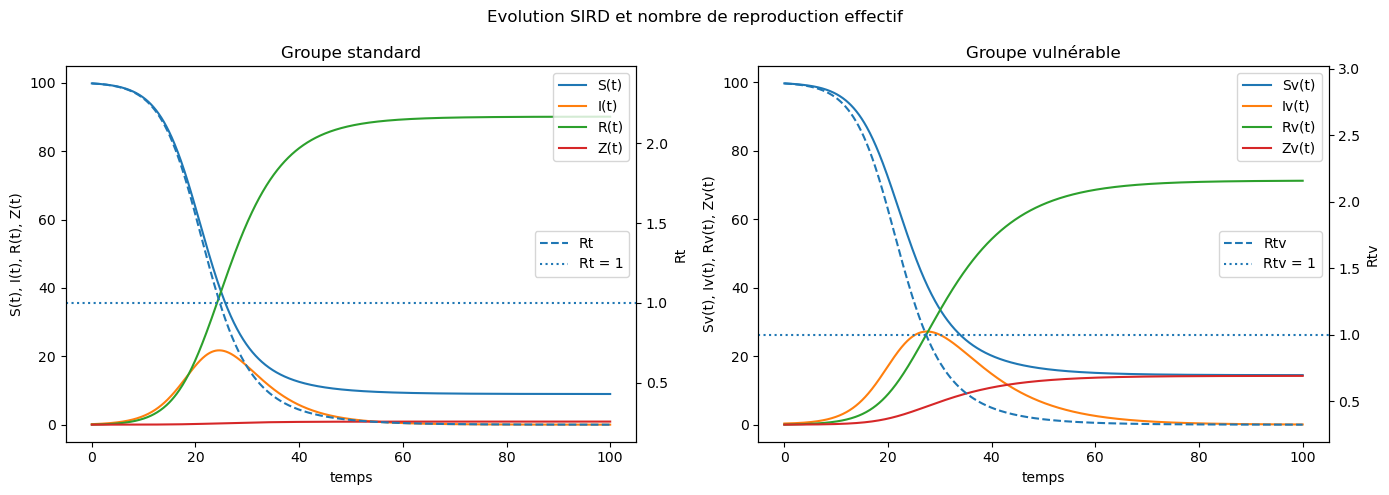

In [38]:
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphe groupe standard ---
ax1.set_title("Groupe standard")
total=S_init+I_init
ax1.plot(temps, S/total*100, label="S(t)")
ax1.plot(temps, I/total*100, label="I(t)")
ax1.plot(temps, R/total*100, label="R(t)")
ax1.plot(temps, Z/total*100, label="Z(t)")
ax1.set_xlabel("temps")
ax1.set_ylabel("S(t), I(t), R(t), Z(t)")
ax1.legend(loc="upper right")

ax2 = ax1.twinx()
ax2.plot(temps, Rt, "--", label="Rt")
ax2.axhline(1, linestyle=":", label="Rt = 1")
ax2.set_ylabel("Rt")
ax2.legend(loc="center right")


# --- Graphe groupe vulnérable ---
ax3.set_title("Groupe vulnérable")
total_v=Sv_init+Iv_init
ax3.plot(temps, Sv/total_v*100, label="Sv(t)")
ax3.plot(temps, Iv/total_v*100, label="Iv(t)")
ax3.plot(temps, Rv/total_v*100, label="Rv(t)")
ax3.plot(temps, Zv/total_v*100, label="Zv(t)")
ax3.set_xlabel("temps")
ax3.set_ylabel("Sv(t), Iv(t), Rv(t), Zv(t)")
ax3.legend(loc="upper right")

ax4 = ax3.twinx()
ax4.plot(temps, Rtv, "--", label="Rtv")
ax4.axhline(1, linestyle=":", label="Rtv = 1")
ax4.set_ylabel("Rtv")
ax4.legend(loc="center right")


plt.suptitle("Evolution SIRD et nombre de reproduction effectif")
plt.tight_layout()
plt.savefig("sir_SIRD_Rt_evolution_2groupes.pdf", bbox_inches="tight")
plt.show()

In [11]:
#stat pour chaque population

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Tailles initiales des 2 groupes
pop_init = S_init + I_init 
pop_init_v = Sv_init + Iv_init
pop_init_tot = pop_init + pop_init_v

# Statistiques finales par groupe
# % de chaque groupe dans la population totale
pct_pop_init = 100 * pop_init / pop_init_tot
pct_pop_init_v = 100 * pop_init_v / pop_init_tot

# % décédés dans chaque groupe à la fin
pct_deces = 100 * Z[-1] / pop_init
pct_deces_v = 100 * Zv[-1] / pop_init_v

# % sains (susceptibles restants) à la fin
pct_sain_fin = 100 * S[-1] / pop_init
pct_sain_fin_v = 100 * Sv[-1] / pop_init_v

# % immunisés (guéris) à la fin
pct_immun_fin = 100 * R[-1] / pop_init
pct_immun_fin_v = 100 * Rv[-1] / pop_init_v

# % immunisés au moment où Rt passe sous 1
pct_immun_seuil = 100 * population_pour_immunite / pop_init
pct_immun_seuil_v = 100 * population_pour_immunite_v / pop_init_v

# =========================
# DataFrame global
# =========================
df_resume = pd.DataFrame({
    "Population": ["Standard", "Vulnérable"],
    "Pop_init (%)": [pct_pop_init, pct_pop_init_v],
    "Immunisés": [pct_immun_fin, pct_immun_fin_v],
    "Sains": [pct_sain_fin, pct_sain_fin_v],
    "Deces": [pct_deces, pct_deces_v],
    "tx_pour_immunité": [pct_immun_seuil, pct_immun_seuil_v],
    "Jour Rt<1": [jour_fin, jour_finV]
})

# Optionnel : arrondi pour affichage
df_resume = df_resume.round({
    "Pop_init (%)": 2,
    "Immunisés": 2,
    "Sains": 2,
    "Deces": 2,
    "tx_pour_immunité": 2,
    "Jour Rt<1": 2
})

display(df_resume)

,Population,Pop_init (%),Immunisés,Sains,Deces,tx_pour_immunité,Jour Rt<1
0,Standard,70.0,90.12,8.97,0.90,60.38,24.8
1,Vulnérable,30.0,71.23,14.46,14.25,58.47,27.4


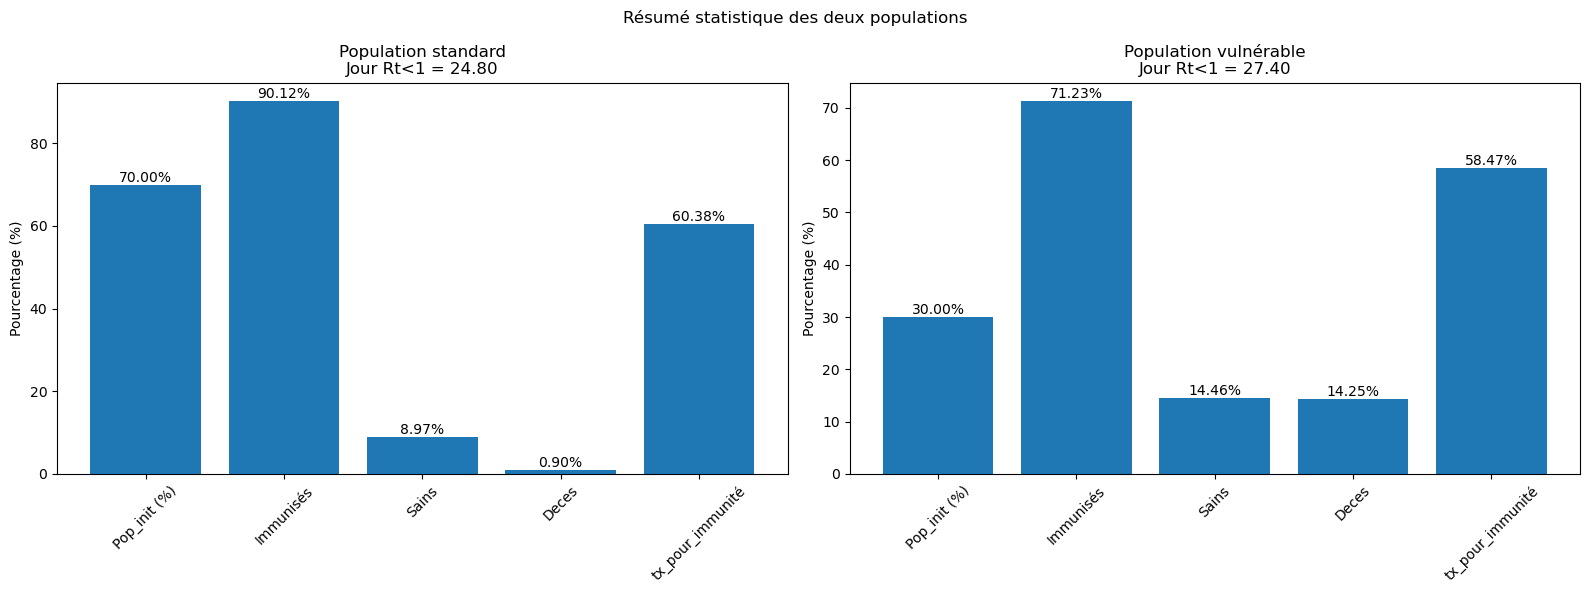

In [40]:
# Colonnes à tracer en pourcentage
cols_pct = [
    "Pop_init (%)",
    "Immunisés",
    "Sains",
    "Deces",
    "tx_pour_immunité"
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------
# Population standard
# -------------------------
val_std = df_resume.loc[df_resume["Population"] == "Standard", cols_pct].iloc[0]

ax1.bar(cols_pct, val_std)
ax1.set_title(
    f"Population standard\nJour Rt<1 = {df_resume.loc[df_resume['Population']=='Standard', 'Jour Rt<1'].iloc[0]:.2f}"
)
ax1.set_ylabel("Pourcentage (%)")
ax1.tick_params(axis="x", rotation=45)

for i, v in enumerate(val_std):
    ax1.text(i, v, f"{v:.2f}%", ha="center", va="bottom")

# -------------------------
# Population vulnérable
# -------------------------
val_v = df_resume.loc[df_resume["Population"] == "Vulnérable", cols_pct].iloc[0]

ax2.bar(cols_pct, val_v)
ax2.set_title(
    f"Population vulnérable\nJour Rt<1 = {df_resume.loc[df_resume['Population']=='Vulnérable', 'Jour Rt<1'].iloc[0]:.2f}"
)
ax2.set_ylabel("Pourcentage (%)")
ax2.tick_params(axis="x", rotation=45)

for i, v in enumerate(val_v):
    ax2.text(i, v, f"{v:.2f}%", ha="center", va="bottom")

plt.suptitle("Résumé statistique des deux populations")
plt.tight_layout()
plt.show()

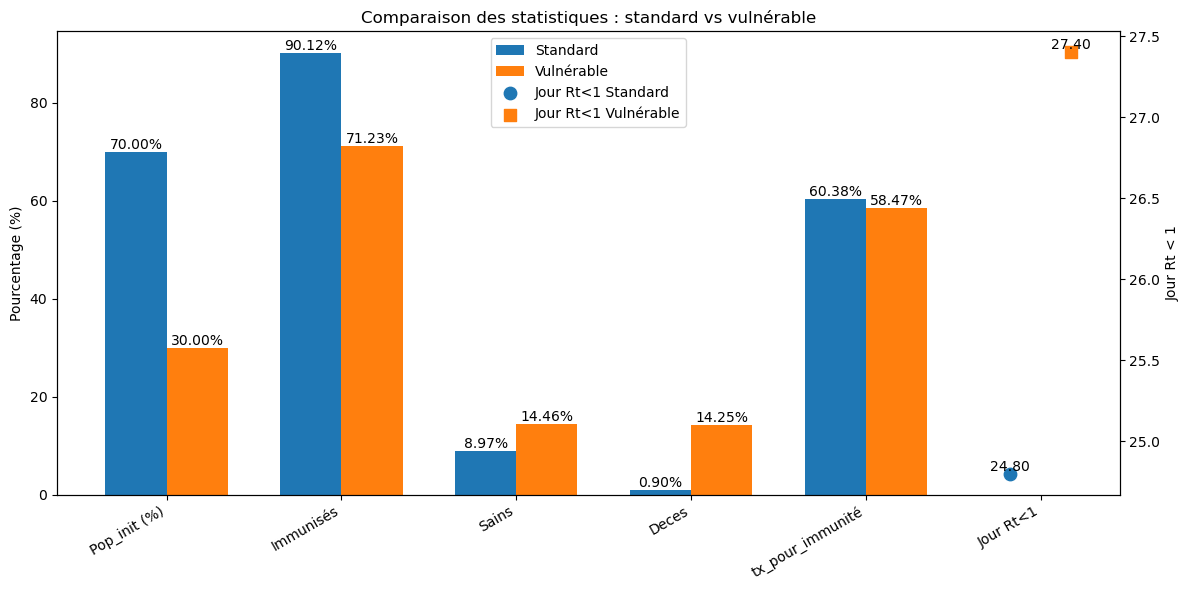

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Statistiques en pourcentage à comparer
stats_pct = ["Pop_init (%)", "Immunisés", "Sains", "Deces", "tx_pour_immunité"]

# Valeurs pour chaque population
vals_std = df_resume.loc[df_resume["Population"] == "Standard", stats_pct].iloc[0].values
vals_vul = df_resume.loc[df_resume["Population"] == "Vulnérable", stats_pct].iloc[0].values

# Jours de passage sous 1
jour_std = df_resume.loc[df_resume["Population"] == "Standard", "Jour Rt<1"].iloc[0]
jour_vul = df_resume.loc[df_resume["Population"] == "Vulnérable", "Jour Rt<1"].iloc[0]

x = np.arange(len(stats_pct))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 6))

# Barres groupées
bar1 = ax1.bar(x - width/2, vals_std, width, label="Standard")
bar2 = ax1.bar(x + width/2, vals_vul, width, label="Vulnérable")

ax1.set_title("Comparaison des statistiques : standard vs vulnérable")
ax1.set_ylabel("Pourcentage (%)")
ax1.set_xticks(x)
ax1.set_xticklabels(stats_pct, rotation=30, ha="right")
ax1.legend(loc="upper left")

# Valeurs au-dessus des barres
for b in bar1:
    h = b.get_height()
    ax1.text(b.get_x() + b.get_width()/2, h, f"{h:.2f}%", ha="center", va="bottom")

for b in bar2:
    h = b.get_height()
    ax1.text(b.get_x() + b.get_width()/2, h, f"{h:.2f}%", ha="center", va="bottom")

# Axe secondaire pour le jour Rt<1
ax2 = ax1.twinx()
ax2.set_ylabel("Jour Rt < 1")

# On place les deux points "jour" à droite du graphe
x_jour = len(stats_pct)
ax2.scatter(x_jour - width/2, jour_std, marker="o", s=80, label="Jour Rt<1 Standard")
ax2.scatter(x_jour + width/2, jour_vul, marker="s", s=80, label="Jour Rt<1 Vulnérable")

ax2.text(x_jour - width/2, jour_std, f"{jour_std:.2f}", ha="center", va="bottom")
ax2.text(x_jour + width/2, jour_vul, f"{jour_vul:.2f}", ha="center", va="bottom")

# Ajouter le libellé de cette dernière catégorie
xticks = list(x) + [x_jour]
xlabels = stats_pct + ["Jour Rt<1"]
ax1.set_xticks(xticks)
ax1.set_xticklabels(xlabels, rotation=30, ha="right")

# Fusion des légendes
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper center")

plt.tight_layout()
plt.savefig("sir_SIRD_Rt_stats_finales_2groupes.pdf", bbox_inches="tight")
plt.show()
